In [1]:
#!pip install GPy
#!pip3 install pyro-ppl

# Loading the modules and packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import GPy
import pandas as pd
import os
import torch
from torch.nn import Parameter

import pyro
import pyro.contrib.gp as gp
import pyro.distributions as dist
import pyro.ops.stats as stats
import scipy.io as sio

smoke_test = ('CI' in os.environ)  # ignore; used to check code integrity in the Pyro repo
assert pyro.__version__.startswith('1.9.1')
pyro.set_rng_seed(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
# load the dataset
dataframe = pd.read_csv('../data/IndianPines.csv', header=0)

In [6]:
df_input = dataframe.iloc[:, :-1]
dataset = df_input.values
print(dataset.shape)

(21025, 200)


# Normalized Pixel values

In [ ]:

# Normalize the pixel values

# Do not divide if a single row contains all zeros to avoid NaN values after normalization
out = np.zeros((dataset.shape))
row_max = np.max(dataset, axis=1, keepdims=True)
new = np.divide(
    dataset,
    row_max,
    out=out,
    where=row_max != 0
)


# Loading all the pixel labes

In [8]:
# Loading all pixel labels
labels_flat = sio.loadmat('../data/Indian_pines_gt.mat')['indian_pines_gt'].reshape(-1)
print("labels_flat shape: ", labels_flat.shape)
print("Data Labels: ", np.unique(labels_flat))

labels_flat shape:  (21025,)
Data Labels:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


# Preparing input as Pytorch tensor for GPLVM

In [7]:
data = torch.tensor(new, dtype=torch.get_default_dtype())
# we need to transpose data to correct its shape
y = data.t()
y = y.to(device)

print(y.shape)
#print(y)


torch.Size([200, 21025])


In [8]:
Q = 5  # Latent dimension
# we setup the mean of our prior over X
X_prior_mean = torch.zeros(y.size(1), Q) # shape: 21025 x 2 (when Data count: 21025)
known_labels = (labels_flat > 0)  # Exclude 0s (unlabeled) # e.g., values from 1 to 16
labels_raw = labels_flat[known_labels] # e.g., values from 1 to 16

# we scale the time into the interval [0, 1]
labels_scaled = (labels_raw - 1) / (labels_raw.max() - 1 )
# labels_scaled = (labels_raw - labels_raw.mean()) / labels_raw.std() # Instead of [0, 1], scale labels to be centered: Gaussian-Like Scaling

# Example: encode class index into the first latent dim
X_prior_mean[known_labels, 0] = torch.tensor(labels_scaled, dtype=torch.float)
X_prior_mean

tensor([[0.1333, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1333, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1333, 0.0000, 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])

# Setting up the kernel and model

In [9]:
kernel = gp.kernels.RBF(input_dim=Q, lengthscale=torch.ones(Q, device=device), variance=torch.tensor(0.5, device=device))

# we clone here so that we don't change our prior during the course of training
X = Parameter(X_prior_mean.clone().to(device))
#print(X)

# we will use SparseGPRegression model with num_inducing=32;
# initial values for Xu are sampled randomly from X_prior_mean
Xu = stats.resample(X_prior_mean.clone(), 64).to(device)
#print(Xu)
print(X.shape, y.shape, Xu.shape)

#likelihood = gp.likelihoods.MultiClass(num_classes=2)

gplvm = gp.models.SparseGPRegression(X, y, kernel, Xu, noise=torch.tensor(0.01, device=device), jitter=1e-5)

torch.Size([21025, 5]) torch.Size([200, 21025]) torch.Size([64, 5])


In [10]:
# we use `.to_event()` to tell Pyro that the prior distribution for X has no batch_shape
gplvm.X = pyro.nn.PyroSample(dist.Normal(X_prior_mean.to(device), 0.1).to_event())
gplvm.autoguide("X", dist.Normal)

In [11]:
losses = gp.util.train(gplvm, num_steps=4000)

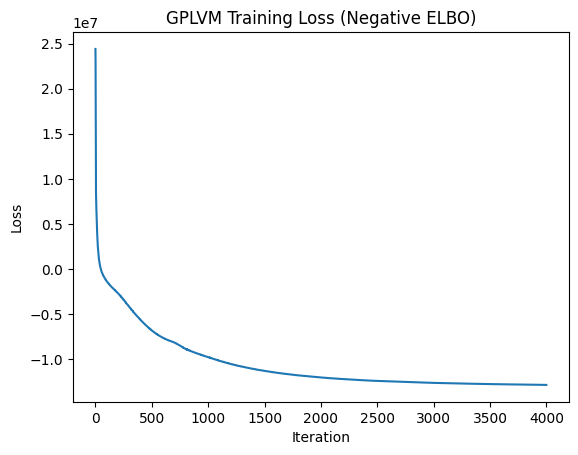

In [12]:
# let's plot the loss curve after 4000 steps of training
plt.plot(losses)
plt.title("GPLVM Training Loss (Negative ELBO)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
#plt.grid(True)
plt.show()

In [ ]:
gplvm.mode = "guide"
X_out = gplvm.X_loc.detach().cpu().numpy()  # draw a sample from the guide of the variable X
print(X_out.shape)

np.save("../model/gplvm_latent_indianpines_5.npy", X_out)

(21025, 5)


In [ ]:
X_out = np.load("../model/gplvm_latent_indianpines_5.npy")

In [ ]:
# If working inside PyTorch ecosystem
X_tensor = torch.tensor(X_out).to(device)
torch.save(X_tensor, "../model/gplvm_latent_indianpines_5.pt")

# GPLVM Performance Evaluation

In [16]:
print(gplvm.X.device)       # latent on GPU or CPU?
print(X_tensor.device)      # input tensor device

cuda:0
cuda:0


In [17]:
# Reconstruction Error (Direct Metric)

# Predict Y from latent space X_out using GP predictive posterior

# Predictive mean (reconstructed Y)
with torch.no_grad():
    y_pred_mean, y_pred_var = gplvm(X_tensor, full_cov=False, noiseless=False)

# Compute MSE or RMSE
recon_mse = torch.mean((y_pred_mean - y)**2).item()
recon_rmse = torch.sqrt(torch.mean((y_pred_mean - y)**2)).item()

print(f"Reconstruction MSE: {recon_mse:.4f}")
print(f"Reconstruction RMSE: {recon_rmse:.4f}")

Reconstruction MSE: 0.0001
Reconstruction RMSE: 0.0097


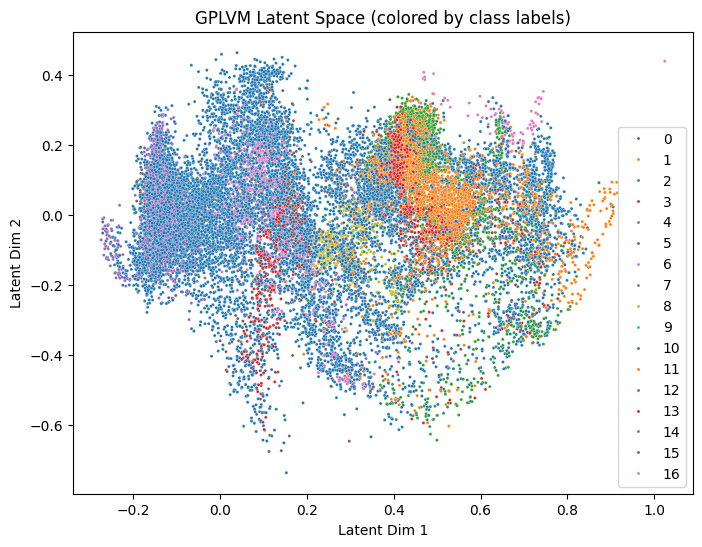

In [18]:
# Latent Space Visualization (Qualitative Metric) - Clear class-wise separation in latent space = useful for downstream segmentation
import seaborn as sns

# Assuming you have class labels loaded: labels_flat.shape = (21025,)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_out[:, 0], y=X_out[:, 1], hue=labels_flat, palette='tab10', s=5, legend='full')
plt.title("GPLVM Latent Space (colored by class labels)")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.show()

# TSNE, UMAP, and Uncertainity map

In [19]:
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

# ---- TSNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
#X_tsne = tsne.fit_transform(X_out)

labels = labels_flat.flatten()

#plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap="tab20", s=2)
#plt.title("t-SNE projection of GPLVM latent space")
#plt.show()

# ---- UMAP
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_out)

#plt.scatter(X_umap[:,0], X_umap[:,1], c=labels, cmap="tab20", s=2)
#plt.title("UMAP projection of GPLVM latent space")
#plt.show()

 /usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(21025, 2)


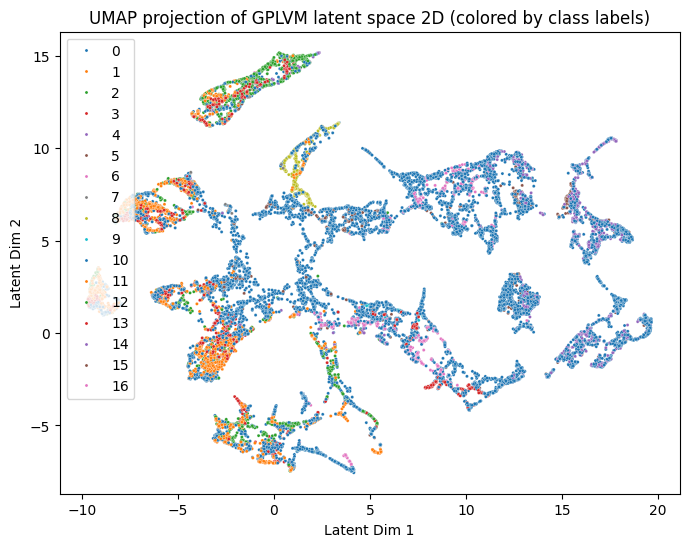

In [20]:
print(X_umap.shape)

# Latent Space Visualization (Qualitative Metric) - Clear class-wise separation in latent space = useful for downstream segmentation
import seaborn as sns

# Assuming you have class labels loaded: labels_flat.shape = (21025,)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=labels_flat, palette='tab10', s=5, legend='full')
plt.title("UMAP projection of GPLVM latent space 2D (colored by class labels)")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.show()

# Uncertainty Map
The GP model gives you predictive variance at each pixel location.
When you do prediction:

In [21]:
X_tensor = torch.tensor(X_out, dtype=torch.float32).to(device)
with torch.no_grad():
    y_pred_mean, y_pred_var = gplvm(X_tensor, full_cov=False, noiseless=False)  #y_pred_mean → reconstructed spectra / prediction, y_pred_var → uncertainty (per pixel, per band).

print("mean:", y_pred_mean.shape)
print("var:", y_pred_var.shape)

mean: torch.Size([200, 21025])
var: torch.Size([200, 21025])


(21025,)
(10249,)


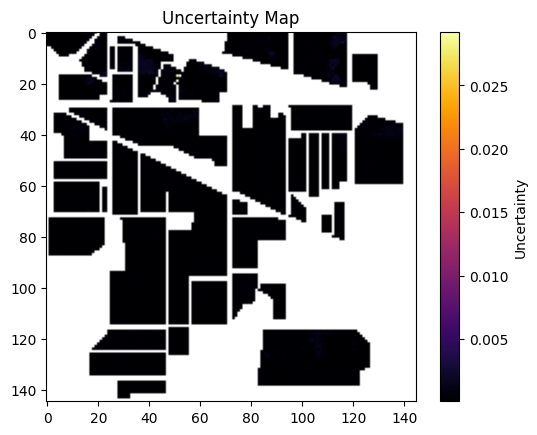

In [22]:
# You can collapse across bands to get a single uncertainty score per pixel:
per_pixel_uncertainty = y_pred_var.mean(dim=0).cpu().numpy()   # average across bands

# Now reshape to the original spatial size (e.g. 145×145 for Indian Pines, 512×217 for Salinas):
# Suppose original image shape
H, W = 145, 145   # Indian Pines
# or H, W = 145, 145 for Indian Pines

# mask is a boolean array with shape (H*W,) telling which pixels are valid
# Example: mask = labels > 0   # if labels were used
mask = known_labels.reshape(-1)   # flatten to 1D
print(mask.shape)
valid_pixel_uncertainty = per_pixel_uncertainty[mask]  # only 54129 pixels
print(valid_pixel_uncertainty.shape)

# Create an empty uncertainty image
uncertainty_map = np.full((H*W,), np.nan)

# Fill only valid pixels with computed uncertainty
uncertainty_map[mask] = valid_pixel_uncertainty

# Reshape back to 2D
uncertainty_map = uncertainty_map.reshape(H, W)

plt.imshow(uncertainty_map, cmap="inferno")
plt.colorbar(label="Uncertainty")
plt.title("Uncertainty Map")
plt.show()

# Clustering Evaluation

In [23]:
# Clustering Evaluation
# clustering metrics to evaluate the alignment of latent space with ground-truth labels:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans

# Use KMeans on X_out
n_clusters = len(np.unique(labels_flat[labels_flat > 0]))
kmeans = KMeans(n_clusters=n_clusters).fit(X_out)
pred_labels = kmeans.labels_

# Evaluate on non-zero ground-truth regions
true_labels = labels_flat[labels_flat > 0]
pred_labels_eval = pred_labels[labels_flat > 0]

ari = adjusted_rand_score(true_labels, pred_labels_eval)
nmi = normalized_mutual_info_score(true_labels, pred_labels_eval)

print(f"ARI: {ari:.4f}, NMI: {nmi:.4f}")

ARI: 0.1997, NMI: 0.4086


# SVM Accuracy on latent features

In [24]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_labeled = X_out[labels_flat > 0]
y_labeled = labels_flat[labels_flat > 0]

X_train, X_test, y_train, y_test = train_test_split(X_labeled, y_labeled, test_size=0.3, stratify=y_labeled)

clf = SVC()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"SVM Accuracy on Latent Features: {acc:.4f}")

SVM Accuracy on Latent Features: 0.6810
